In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv('/content/heart.csv')

In [ ]:
X = df.drop('target', axis=1)
y = df['target']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 1. Train and visualize Decision Tree
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

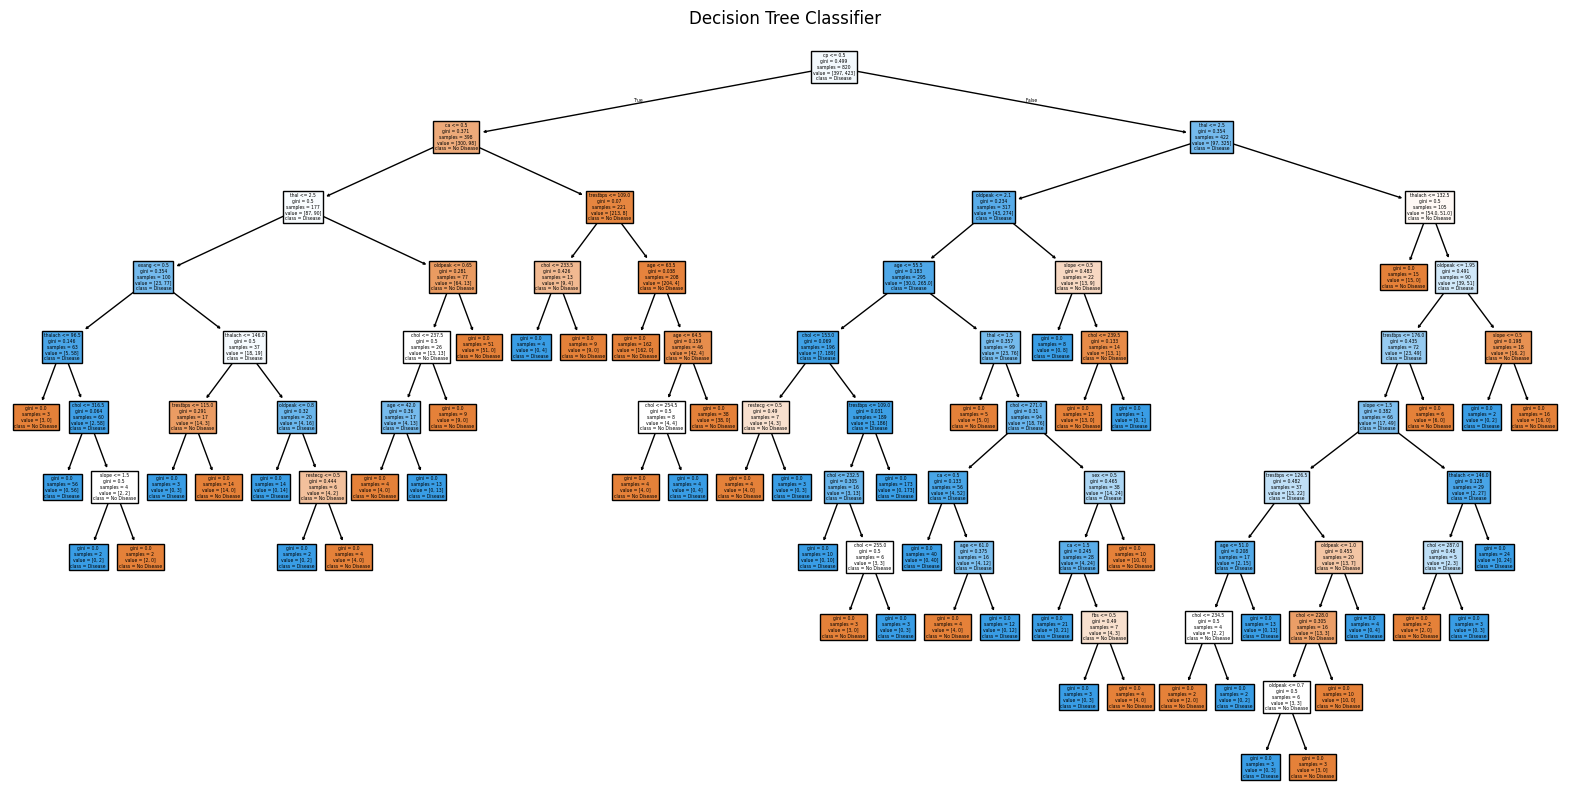

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(tree_clf, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=True)
plt.title("Decision Tree Classifier")
plt.show()

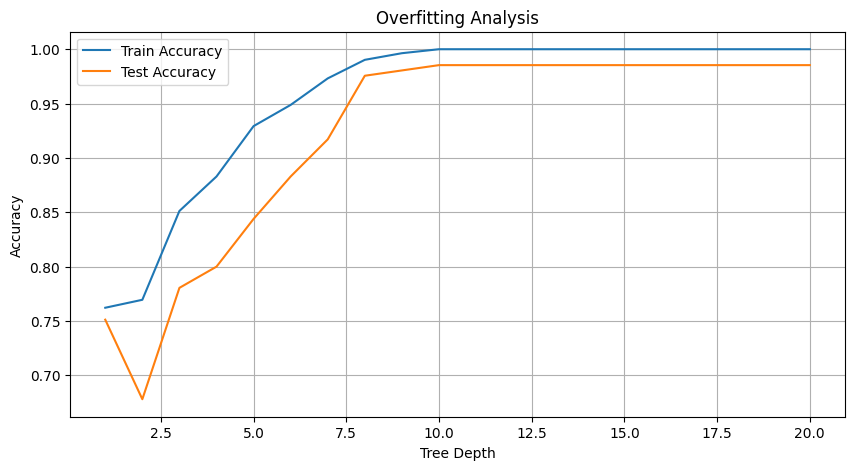

In [ ]:
# Analyzing overfitting by varying max_depth
train_scores = []
test_scores = []
depth_range = range(1, 21)
for depth in depth_range:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(depth_range, train_scores, label='Train Accuracy')
plt.plot(depth_range, test_scores, label='Test Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Overfitting Analysis')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Training Random Forest and comparing accuracy
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

rf_preds = rf_clf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_preds)
print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:\n", classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.9853658536585366

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



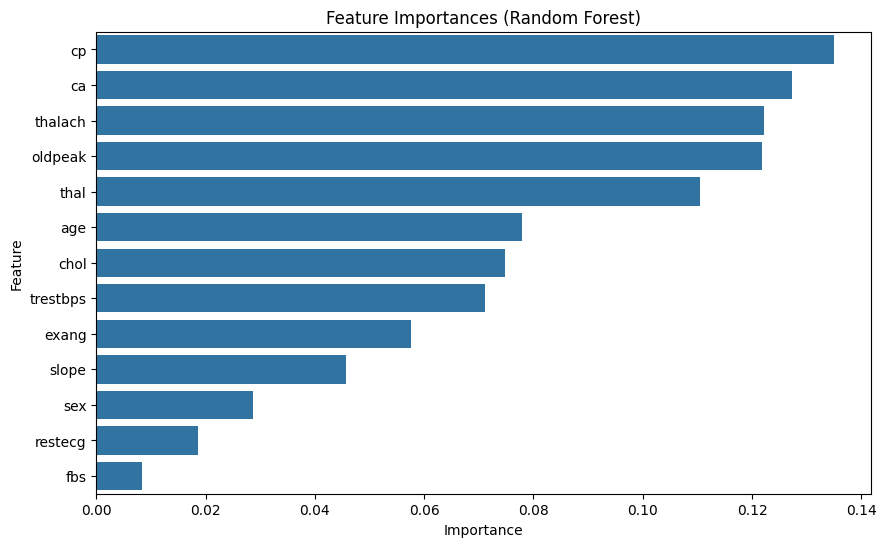

In [ ]:
# Feature Importances
importances = rf_clf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df)
plt.title('Feature Importances (Random Forest)')
plt.show()


In [ ]:
# Cross-Validation Accuracy
cv_scores_tree = cross_val_score(tree_clf, X, y, cv=5)
cv_scores_rf = cross_val_score(rf_clf, X, y, cv=5)

print(f"Decision Tree CV Accuracy: {cv_scores_tree.mean():.4f}")
print(f"Random Forest CV Accuracy: {cv_scores_rf.mean():.4f}")

Decision Tree CV Accuracy: 1.0000
Random Forest CV Accuracy: 0.9971
